In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add the 'src' directory to the path to import our custom modules
sys.path.append(os.path.abspath(os.path.join('..')))

from src.engine import RiskEngine
from src.data_gen import MarketDataGenerator, PortfolioGenerator

# Plot styling for professional look
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

Project Setup & Data Generation

First, we initialize the Risk Engine and generate dummy market data (Forward Curves, Volatility) and a sample Trading Portfolio.

Base Date: Jan 1st, 2025

Horizon: 24 Months

In [2]:
# 1. Configuration
BASE_DATE = pd.Timestamp('2025-01-01')
HORIZON_MONTHS = 24

# 2. Generate Market Data (Curves & Discount Factors)
fwd_curves = MarketDataGenerator.generate_forward_curves(BASE_DATE, HORIZON_MONTHS)
discount_curve = MarketDataGenerator.generate_discount_curve(BASE_DATE, HORIZON_MONTHS)

# 3. Generate Risk Matrix (Covariance)
# We map vertices: M1..M12 (First 12 months) + Y2 (Second Year)
vertices = [f'M{i}' for i in range(1, 13)] + ['Y1']
risk_matrix = MarketDataGenerator.generate_risk_matrix(vertices)

# 4. Generate Portfolio (Energy Balance)
portfolio_balance = PortfolioGenerator.generate_energy_balance(BASE_DATE, HORIZON_MONTHS)

# Display sample data
print("--- Sample Portfolio Data ---")
display(portfolio_balance.head())

print("\n--- Forward Curves Snapshot (BRL/MWh) ---")
display(fwd_curves.head())

--- Sample Portfolio Data ---


,Date,Submarket,Source,Portfolio,MW_Avg
0,2025-01-01,NE,Solar,Trading,51.442847
1,2025-01-01,SE,Contract,Trading,-31.285093
2,2025-02-01,NE,Solar,Trading,51.853962
3,2025-02-01,SE,Contract,Trading,-32.501224
4,2025-03-01,NE,Solar,Trading,55.167196



--- Forward Curves Snapshot (BRL/MWh) ---


,2025-01-01,2025-02-01,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01,...,2026-03-01,2026-04-01,2026-05-01,2026-06-01,2026-07-01,2026-08-01,2026-09-01,2026-10-01,2026-11-01,2026-12-01
NE,95.433017,117.107676,130.624978,139.748372,124.08133,111.986480,104.373014,84.978147,70.449753,71.776998,...,129.506054,139.017980,127.457719,113.677335,106.260271,86.931045,88.412803,93.240422,98.728515,113.107106
SE,102.984003,128.713305,141.091294,155.128614,134.88940,120.282186,111.170110,95.455019,75.446307,77.707271,...,145.087163,153.946732,139.643956,126.925818,115.879858,94.083241,98.040695,101.285612,107.061762,125.095725


Market Analysis

Visualizing the Forward Price Curves generated for the Southeast (SE) and South (S) submarkets.

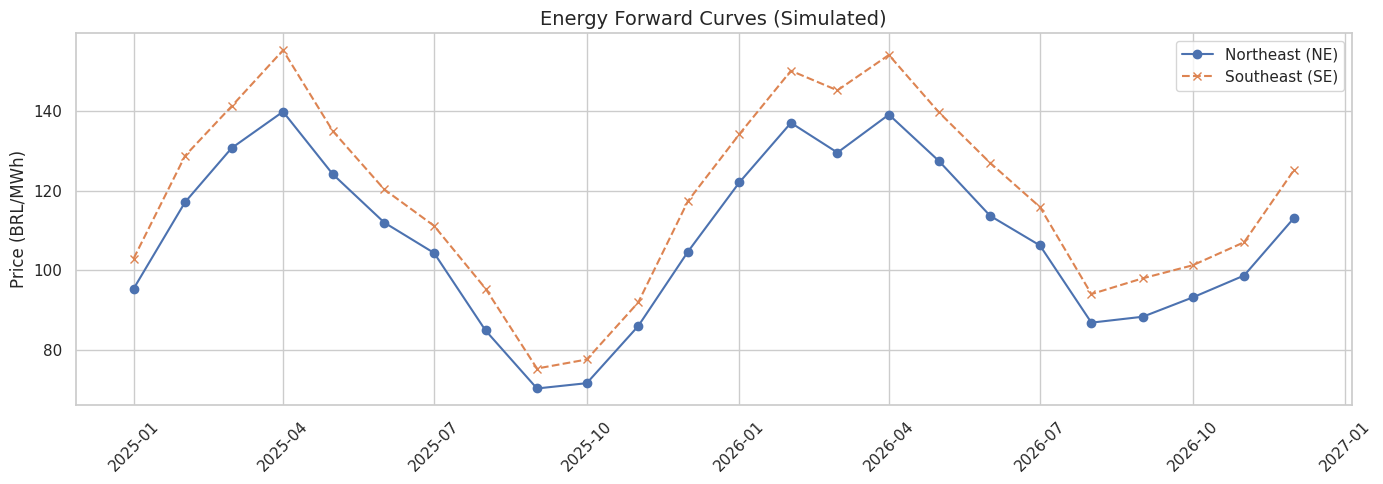

In [4]:
plt.figure(figsize=(14, 5))
plt.plot(fwd_curves.columns, fwd_curves.loc['NE'], label='Northeast (NE)', marker='o')
plt.plot(fwd_curves.columns, fwd_curves.loc['SE'], label='Southeast (SE)', marker='x', linestyle='--')

plt.title('Energy Forward Curves (Simulated)', fontsize=14)
plt.ylabel('Price (BRL/MWh)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Mark-to-Market (MtM) Calculation

We calculate the fair value of the portfolio by comparing the contracted positions against the current forward curves, discounting the cash flows to the Base Date.

2026-02-04 02:28:34,758 - src.engine - INFO - Starting MtM calculation...
2026-02-04 02:28:34,767 - src.engine - INFO - MtM calculation finished. Total Value: BRL 29,070,343.56


Total Portfolio MtM: BRL 29,070,343.56


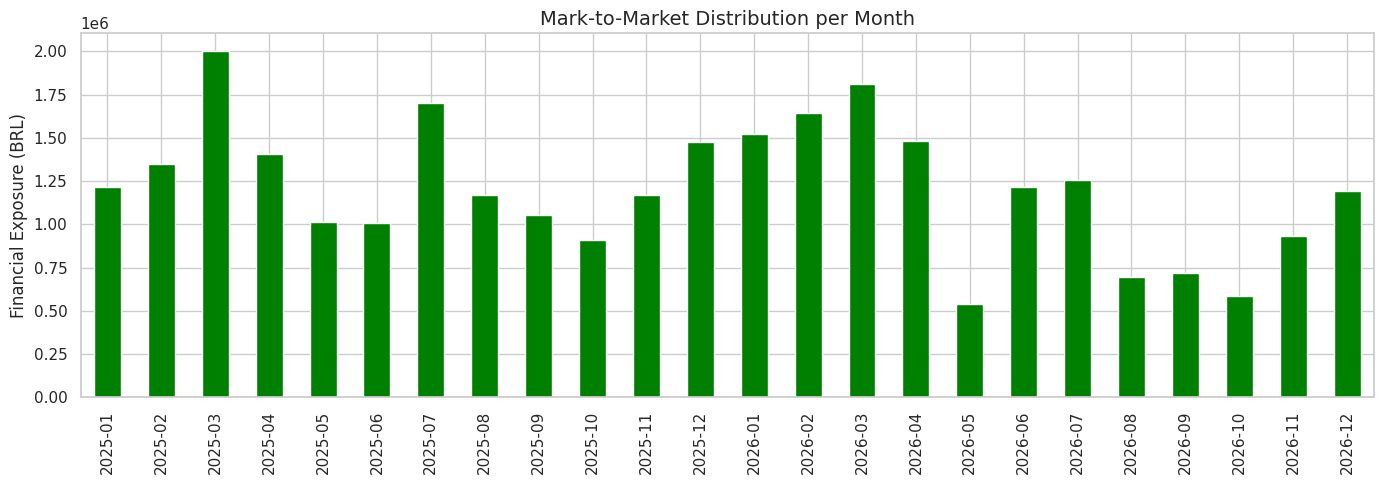

In [5]:
# Initialize Engine
engine = RiskEngine()

# Calculate MtM
mtm_matrix, total_mtm = engine.calculate_mtm(portfolio_balance, fwd_curves, discount_curve)

print(f"Total Portfolio MtM: BRL {total_mtm:,.2f}")

# Visualizing MtM per Month
mtm_per_month = mtm_matrix.sum()
mtm_per_month.index = mtm_per_month.index.strftime('%Y-%m')

plt.figure(figsize=(14, 5))
colors = ['green' if x > 0 else 'red' for x in mtm_per_month]
mtm_per_month.plot(kind='bar', color=colors)
plt.title('Mark-to-Market Distribution per Month', fontsize=14)
plt.ylabel('Financial Exposure (BRL)')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

Parametric VaR Calculation

Here we estimate the Value at Risk (VaR) with 95% confidence. The engine maps the monthly exposures to the risk vertices (M1, M2... Y1) and applies the Delta-Normal approach.

2026-02-04 02:28:37,399 - src.engine - INFO - Starting Parametric VaR calculation...
2026-02-04 02:28:37,411 - src.engine - INFO - VaR calculated: BRL 3,185,859.17 (Confidence: 95.0%)


Parametric VaR (95%): BRL 3,185,859.17


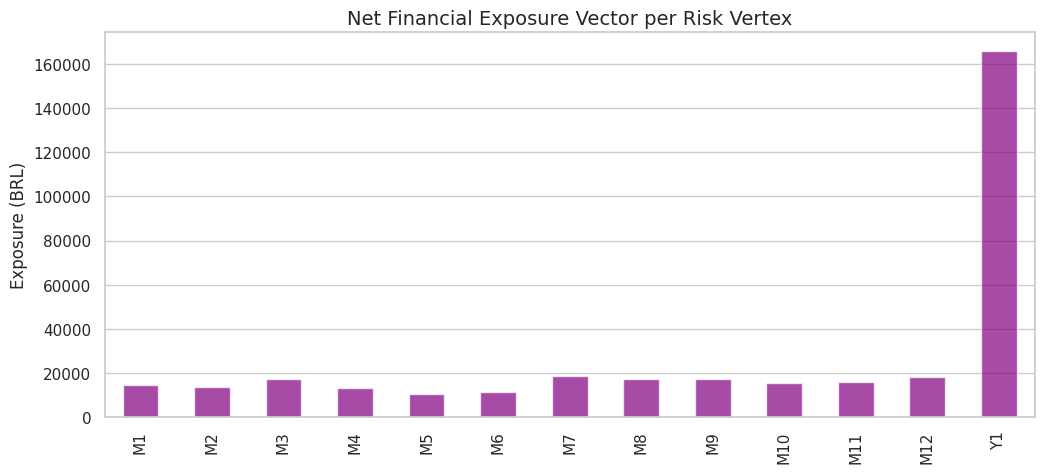

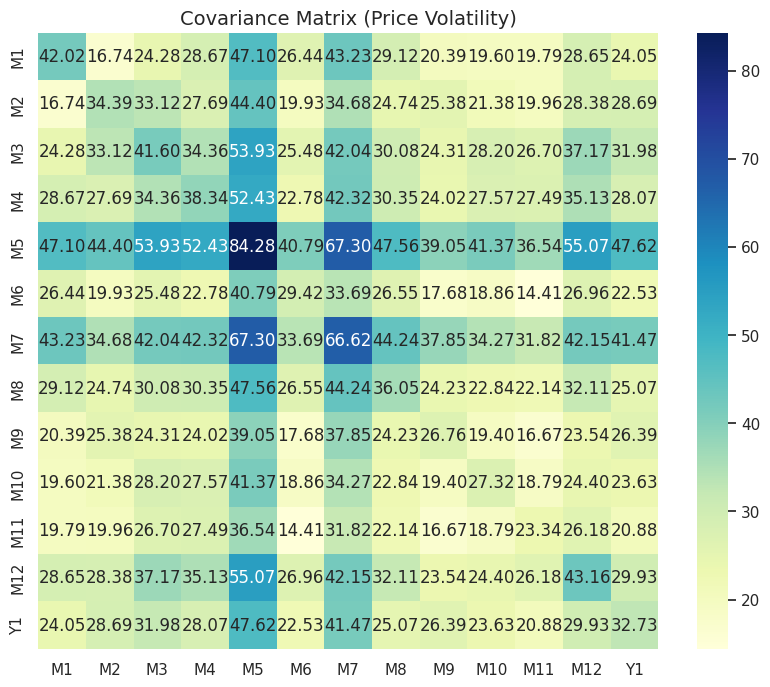

In [6]:
# Calculate VaR
var_value, exposure_financial = engine.calculate_parametric_var(portfolio_balance, risk_matrix, BASE_DATE)

print(f"Parametric VaR (95%): BRL {var_value:,.2f}")

# Visualize the Net Financial Exposure Vector (s vector) used in VaR
plt.figure(figsize=(12, 5))
exposure_financial.plot(kind='bar', color='purple', alpha=0.7)
plt.title('Net Financial Exposure Vector per Risk Vertex', fontsize=14)
plt.ylabel('Exposure (BRL)')
plt.grid(axis='x')
plt.show()

# Visualize Risk Matrix (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(risk_matrix, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title('Covariance Matrix (Price Volatility)', fontsize=14)
plt.show()